# Machine Learning Tutorial: hands-on with JAX

Tutorial for the lecture series *Machine Learning for Physicists*.

In a previous tutorial ([01_tutorial_CurveFitting.ipynb](01_tutorial_CurveFitting.ipynb)) you fitted a function with hand-coded gradients in NumPy. In this notebook you will repeat that exercise, but now using **JAX** to compute the gradients automatically.

The notebook is split in two parts:

- **Part 1** &mdash; a short refresher on `jax.grad` and gradient-based optimization (using `optax`) on a toy function.
- **Part 2** &mdash; using JAX to fit a parameterized function, repeating the examples of the previous tutorial.

---
## Part 1: A quick reminder on JAX

JAX behaves much like NumPy, but on top it gives you:

- **`jax.grad`** &mdash; automatic differentiation of any Python function that returns a scalar.
- **`jax.jit`** &mdash; just-in-time compilation (we will not need it here).
- A growing ecosystem of libraries; we will use **`optax`** for the optimizers.

##### Imports

In [1]:
import jax
import jax.numpy as jnp
import optax

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

##### A toy function with a known minimum

We consider a simple two-parameter function

$$ f(\theta) = (\theta_0 - 1)^2 + 4\,(\theta_1 + 2)^2 $$

with the obvious minimum at $\theta^\star = (1, -2)$. The two directions have different curvatures, so the level sets are elongated ellipses &mdash; a good situation to compare optimizers.

In [2]:
def f(theta):
    return (theta[0] - 1.0)**2 + 4.0 * (theta[1] + 2.0)**2

theta_star = jnp.array([1.0, -2.0])

Visualize the loss landscape.

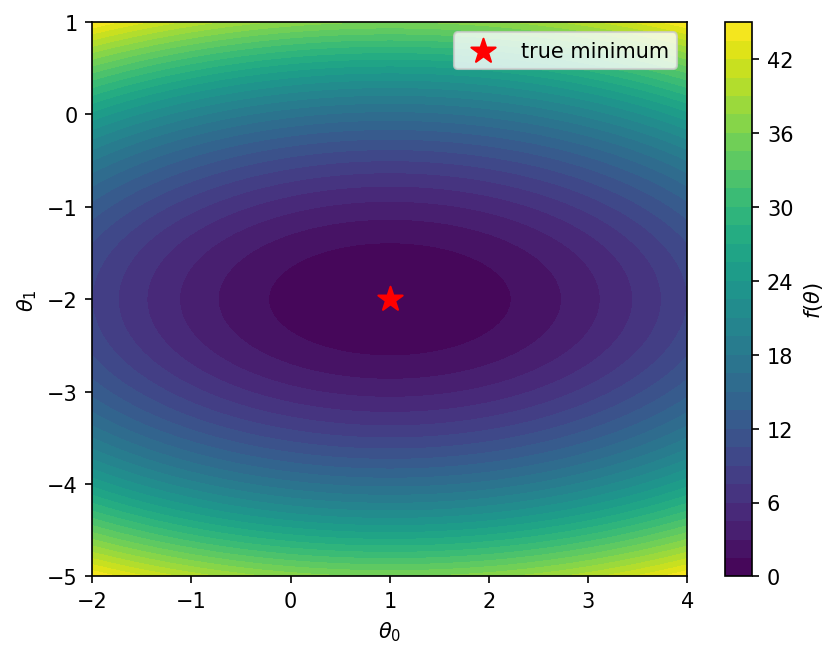

In [3]:
t0 = jnp.linspace(-2.0, 4.0, 100)
t1 = jnp.linspace(-5.0, 1.0, 100)
T0, T1 = jnp.meshgrid(t0, t1, indexing='ij')
Z = (T0 - 1.0)**2 + 4.0 * (T1 + 2.0)**2

plt.contourf(T0, T1, Z, 30)
plt.colorbar(label=r'$f(\theta)$')
plt.scatter([theta_star[0]], [theta_star[1]], marker='*', color='red', s=150, label='true minimum')
plt.xlabel(r'$\theta_0$')
plt.ylabel(r'$\theta_1$')
plt.legend()
plt.show()

##### Computing the gradient with `jax.grad`

`jax.grad(f)` returns a *new function* that, when called on $\theta$, gives $\nabla_\theta f(\theta)$. By default the gradient is taken with respect to the first argument.

For our toy function the analytical gradient is

$$ \nabla_\theta f(\theta) = \big(\,2(\theta_0 - 1),\; 8(\theta_1 + 2)\,\big). $$

Let us verify that JAX gets the same result.

In [ ]:
# the function grad_f will calculate the gradient of f via automatic differentiation
grad_f = jax.grad(f)

# for comparison, we have implemented the analytical expression for the gradient
def grad_f_analytic(theta):
    return jnp.array([2.0 * (theta[0] - 1.0), 8.0 * (theta[1] + 2.0)])

for theta_test in [jnp.array([0.0, 0.0]),
                   jnp.array([3.0, -1.0]),
                   jnp.array([-1.5, 2.5])]:
    print(f"theta = {theta_test}")
    print(f"   jax.grad  : {grad_f(theta_test)}")
    print(f"   analytical: {grad_f_analytic(theta_test)}")

theta = [0. 0.]
   jax.grad  : [-2. 16.]
   analytical: [-2. 16.]
theta = [ 3. -1.]
   jax.grad  : [4. 8.]
   analytical: [4. 8.]
theta = [-1.5  2.5]
   jax.grad  : [-5. 36.]
   analytical: [-5. 36.]


##### Manual gradient descent

Update rule:

$$ \theta^{(n+1)} = \theta^{(n)} - \eta \, \nabla_\theta f(\theta^{(n)}). $$

We record the full trajectory so that we can plot it on top of the contour and watch the loss go down.

In [5]:
theta = jnp.array([-1.0, 0.5])  # arbitrary starting point
eta = 0.1                        # learning rate
nsteps = 50

trajectory_sgd = [theta]
loss_sgd = [f(theta)]

for n in range(nsteps):
    theta = theta - eta * grad_f(theta)
    trajectory_sgd.append(theta)
    loss_sgd.append(f(theta))

trajectory_sgd = jnp.array(trajectory_sgd)
loss_sgd = jnp.array(loss_sgd)

print(f"Final theta : {theta}")
print(f"True minimum: {theta_star}")

Final theta : [ 0.9999715 -2.       ]
True minimum: [ 1. -2.]


##### The same with `optax`

In practice we rarely implement the update rule by hand. **`optax`** provides a large collection of optimizers (SGD, Adam, RMSProp, ...) behind a common interface. The workflow is always the same:

1. create the optimizer,
2. initialize its state with the current parameters,
3. in the loop: compute the gradient, ask the optimizer for an update, apply it.

Here we use the popular `Adam` optimizer, which adapts the step size per parameter.

In [6]:
optimizer = optax.adam(learning_rate=0.1)

theta = jnp.array([-1.0, 0.5])     # same starting point as above
opt_state = optimizer.init(theta)

trajectory_adam = [theta]
loss_adam = [f(theta)]

for n in range(nsteps):
    grads = grad_f(theta)
    updates, opt_state = optimizer.update(grads, opt_state)
    theta = optax.apply_updates(theta, updates)
    trajectory_adam.append(theta)
    loss_adam.append(f(theta))

trajectory_adam = jnp.array(trajectory_adam)
loss_adam = jnp.array(loss_adam)

print(f"Final theta : {theta}")
print(f"True minimum: {theta_star}")

Final theta : [ 1.075768  -2.1918776]
True minimum: [ 1. -2.]


##### Comparison

Left: the two trajectories on the loss landscape. Right: the loss as a function of the optimization step (log scale).

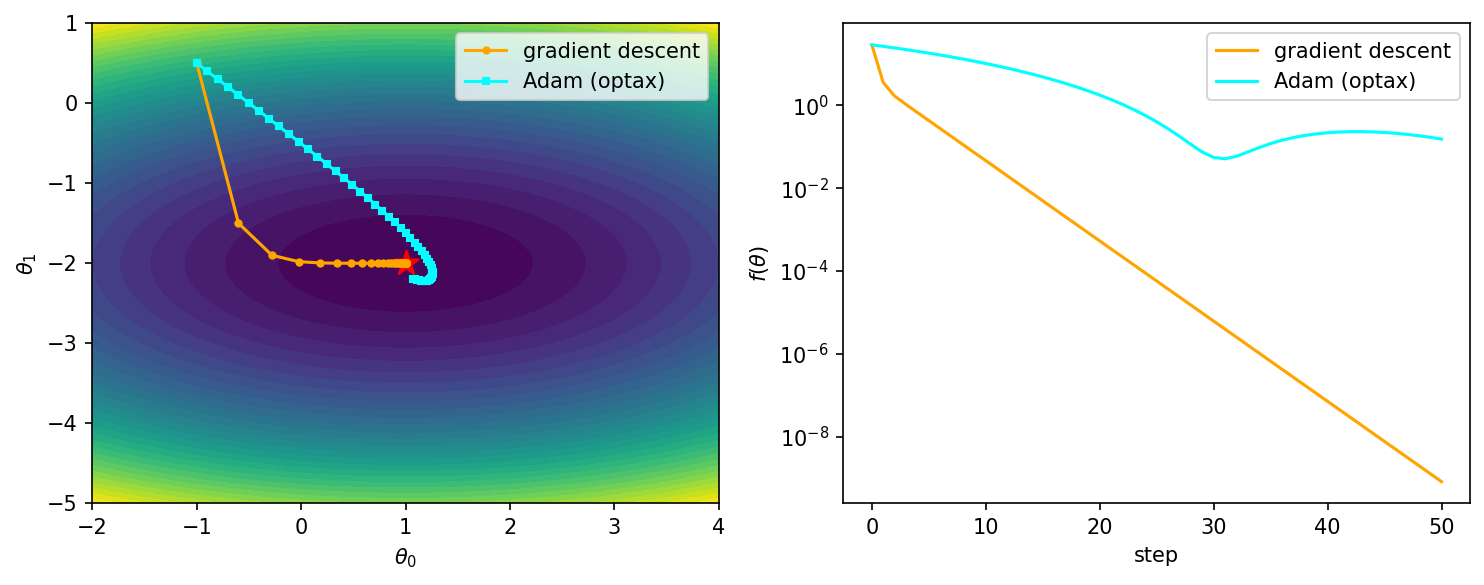

In [7]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(10, 4))

ax[0].contourf(T0, T1, Z, 30)
ax[0].plot(trajectory_sgd[:, 0], trajectory_sgd[:, 1], 'o-', color='orange', markersize=3, label='gradient descent')
ax[0].plot(trajectory_adam[:, 0], trajectory_adam[:, 1], 's-', color='cyan', markersize=3, label='Adam (optax)')
ax[0].scatter([theta_star[0]], [theta_star[1]], marker='*', color='red', s=150)
ax[0].set_xlabel(r'$\theta_0$')
ax[0].set_ylabel(r'$\theta_1$')
ax[0].legend()

ax[1].semilogy(loss_sgd, color='orange', label='gradient descent')
ax[1].semilogy(loss_adam, color='cyan', label='Adam (optax)')
ax[1].set_xlabel('step')
ax[1].set_ylabel(r'$f(\theta)$')
ax[1].legend()

plt.tight_layout()
plt.show()

---
## Part 2: Function fitting with JAX

*(to be developed in the next step)*